# Classify CLOSED/OPEN EYE with Keras and MobileNet

## Step 1: Data Preprocessing

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

DATASET_PATH = "dataset/eye-dataset/"  # Included 3 folders: train, val, test
IMG_SIZE = 128 #Change: Increase IMG_SIZE        
BATCH_SIZE = 96 #Change: Increase BATCH_SIZE

# 1. Load Training
train_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'train'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 2. Load Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'val'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 3. Load Test
test_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'test'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"\nList of Labels found by Keras: {class_names}")

Found 139804 files belonging to 2 classes.
Found 27961 files belonging to 2 classes.
Found 6991 files belonging to 2 classes.

List of Labels found by Keras: ['closed', 'open']


In [2]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


## Step 2: Load the MobileNetV2 Structure

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Transfer Learning:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Unfreeze the last 20 layers to learn the fine details of "Eyelashes" and "Irises"
for layer in base_model.layers[-20:]:
    layer.trainable = True

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) ##Change: 0.4 -> 0.5
x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x) ##Change: Add L2
outputs = Dense(1, activation='sigmoid')(x) # sigmoid since the output is binary: 0 or 1

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 1,247,105 (4.76 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

## Step 3: Do Training Model

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_blink_mobilenet.h5", save_best_only=True)

##Change: Add ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9484 - loss: 0.5712

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 248s 168ms/step - accuracy: 0.9711 - loss: 0.3726 - val_accuracy: 0.9723 - val_loss: 0.1606 - learning_rate: 1.0000e-04
Epoch 2/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9849 - loss: 0.0986

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 235s 162ms/step - accuracy: 0.9867 - loss: 0.0749 - val_accuracy: 0.9814 - val_loss: 0.0647 - learning_rate: 1.0000e-04
Epoch 3/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9902 - loss: 0.0372

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 236s 162ms/step - accuracy: 0.9917 - loss: 0.0312 - val_accuracy: 0.9810 - val_loss: 0.0573 - learning_rate: 1.0000e-04
Epoch 4/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 226s 155ms/step - accuracy: 0.9953 - loss: 0.0182 - val_accuracy: 0.9759 - val_loss: 0.0855 - learning_rate: 1.0000e-04
Epoch 5/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9963 - loss: 0.0148
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 226s 155ms/step - accuracy: 0.9966 - loss: 0.0136 - val_accuracy: 0.9420 - val_loss: 0.2182 - learning_rate: 1.0000e-04
Epoch 6/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9979 - loss: 0.0098

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 240s 165ms/step - accuracy: 0.9985 - loss: 0.0078 - val_accuracy: 0.9873 - val_loss: 0.0521 - learning_rate: 5.0000e-05
Epoch 7/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 237s 163ms/step - accuracy: 0.9993 - loss: 0.0053 - val_accuracy: 0.9852 - val_loss: 0.0640 - learning_rate: 5.0000e-05
Epoch 8/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9993 - loss: 0.0052
Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 237s 163ms/step - accuracy: 0.9993 - loss: 0.0049 - val_accuracy: 0.9856 - val_loss: 0.0697 - learning_rate: 5.0000e-05
Epoch 9/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 238s 163ms/step - accuracy: 0.9996 - loss: 0.0032 - val_accuracy: 0.9887 - val_loss: 0.0526 - learning_rate: 2.5000e-05
Epoch 10/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9998 - loss: 0.0026
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 276s 190m

## Step 4: Evaluation

73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9888 - loss: 0.0414

Last Accuracy on Test: 98.88%


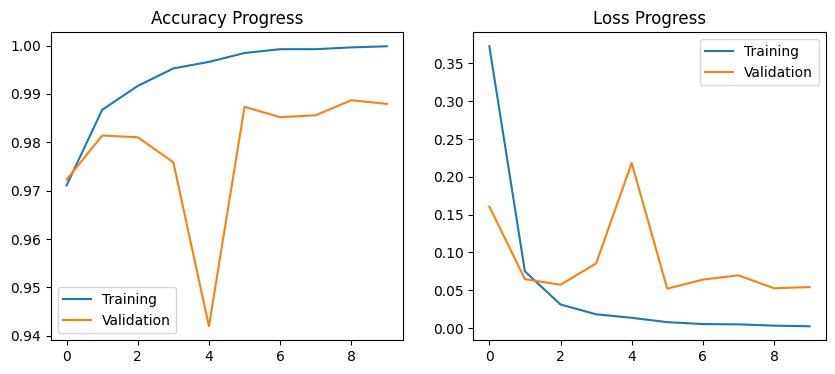

In [5]:
loss, acc = model.evaluate(test_ds)
print(f"\nLast Accuracy on Test: {acc*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Progress')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Progress')
plt.legend()
plt.show()

## Bước 5: Sang số, vác Model đi thực chiến (ONNX Export)

In [6]:
import tf2onnx

spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
output_path = "mobilenet_eye_blink.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=output_path)
output_names = [n.name for n in model_proto.graph.output]
print(f"\nSuccessfully exported to ONNX! Output file: {output_path}")
print(f"Please note down the Input Name: input, Output Name: {output_names}")

I0000 00:00:1776047805.456704  467936 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776047805.456773  467936 single_machine.cc:376] Starting new session
I0000 00:00:1776047805.875750  467936 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776047805.875817  467936 single_machine.cc:376] Starting new session



Successfully exported to ONNX! Output file: mobilenet_eye_blink.onnx
Please note down the Input Name: input, Output Name: ['dense_1']
